# Checkpoint 1: PR Merge Outcomes on GitHub

This notebook is a structured skeleton for the first project checkpoint in FEUP's Data Analysis in Software Engineering course. It is intentionally limited to problem framing, dataset scoping, data-quality review, schema auditing, leakage-aware feature screening, and initial exploratory analysis planning for the PR-level dataset.

Checkpoint 1 is explicitly limited to problem understanding, target audit, data quality, leakage awareness, and initial EDA on conservative safe features. No predictive modelling is performed yet.

In [2]:
# Setup imports and notebook defaults
from __future__ import annotations

from importlib.metadata import version
from io import StringIO
from pathlib import Path

try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from IPython.display import Markdown, display
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Missing notebook dependencies. In VS Code, select the project .venv interpreter or install: pandas numpy matplotlib seaborn jupyter ipykernel"
    ) from exc

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE = 42
TARGET_LABELS = {0: "Not merged", 1: "Merged"}
LIBRARY_VERSIONS = {
    "numpy": version("numpy"),
    "pandas": version("pandas"),
    "matplotlib": version("matplotlib"),
    "seaborn": version("seaborn"),
}

LIBRARY_VERSIONS


{'numpy': '2.0.2',
 'pandas': '2.3.3',
 'matplotlib': '3.9.4',
 'seaborn': '0.13.2'}

In [3]:
# Configuration: project paths, target, and scope locks
import os

DEFAULT_LOCAL_ROOT = Path("/Users/mahmoudali/Documents/ADES - first project")
PROJECT_ROOT_OVERRIDE = DEFAULT_LOCAL_ROOT if DEFAULT_LOCAL_ROOT.exists() else None
# TODO: If needed on another machine, set PROJECT_ROOT_OVERRIDE to the local project folder or use the ADES_PROJECT_ROOT environment variable.


def is_project_root(path: Path) -> bool:
    return (path / "README.md").exists() and (path / "data").exists()


def candidate_project_roots() -> list[Path]:
    candidates: list[Path] = []

    if PROJECT_ROOT_OVERRIDE is not None:
        candidates.append(Path(PROJECT_ROOT_OVERRIDE).expanduser().resolve())

    env_root = os.environ.get("ADES_PROJECT_ROOT")
    if env_root:
        candidates.append(Path(env_root).expanduser().resolve())

    cwd = Path.cwd().resolve()
    candidates.extend([cwd, *cwd.parents])
    candidates.append(Path.home() / "Documents" / "ADES - first project")

    unique_candidates: list[Path] = []
    seen: set[Path] = set()
    for candidate in candidates:
        if candidate not in seen:
            unique_candidates.append(candidate)
            seen.add(candidate)

    return unique_candidates


def find_project_root() -> Path:
    for candidate in candidate_project_roots():
        if is_project_root(candidate):
            return candidate

    checked_locations = [str(candidate) for candidate in candidate_project_roots()]
    raise FileNotFoundError(
        "Could not locate the project root. Set PROJECT_ROOT_OVERRIDE or ADES_PROJECT_ROOT to your local 'ADES - first project' folder. "
        f"Checked: {checked_locations}"
    )


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "raw"

TRAIN_PATH = DATA_DIR / "prfeatures_train_data.csv"
TEST_PATH = DATA_DIR / "prfeatures_test_data.csv"
TARGET_COLUMN = "merged_or_not"

EXCLUDED_DATASETS = [
    DATA_DIR / "pr_comments_dataset_publish.csv",
    DATA_DIR / "survey_responses_raw.csv",
]

TRAIN_NROWS = None
TEST_NROWS = None
TRAIN_USECOLS = None
TEST_USECOLS = None
CSV_READ_KWARGS = {"low_memory": False}
EDA_PLOT_SAMPLE = 50000

SCOPE_NOTE = (
    "Checkpoint 1 uses the training dataset as the main source and the test dataset only for schema and label consistency checks."
)

required_paths = {
    "train": TRAIN_PATH,
    "test": TEST_PATH,
}
missing_paths = [name for name, file_path in required_paths.items() if not file_path.exists()]
if missing_paths:
    raise FileNotFoundError(
        f"Missing required dataset files: {missing_paths}. Expected them under {DATA_DIR}."
    )

config_summary = {
    "project_root": str(PROJECT_ROOT),
    "train_path": str(TRAIN_PATH),
    "test_path": str(TEST_PATH),
    "target_column": TARGET_COLUMN,
    "excluded_datasets": [str(path) for path in EXCLUDED_DATASETS],
    "train_nrows": TRAIN_NROWS,
    "test_nrows": TEST_NROWS,
    "train_usecols": TRAIN_USECOLS,
    "test_usecols": TEST_USECOLS,
    "csv_read_kwargs": CSV_READ_KWARGS,
    "eda_plot_sample": EDA_PLOT_SAMPLE,
    "scope_note": SCOPE_NOTE,
}

config_summary


{'project_root': '/Users/tesssb/feup/ades-pr-merge-rate-predection',
 'train_path': '/Users/tesssb/feup/ades-pr-merge-rate-predection/data/raw/prfeatures_train_data.csv',
 'test_path': '/Users/tesssb/feup/ades-pr-merge-rate-predection/data/raw/prfeatures_test_data.csv',
 'target_column': 'merged_or_not',
 'excluded_datasets': ['/Users/tesssb/feup/ades-pr-merge-rate-predection/data/raw/pr_comments_dataset_publish.csv',
  '/Users/tesssb/feup/ades-pr-merge-rate-predection/data/raw/survey_responses_raw.csv'],
 'train_nrows': None,
 'test_nrows': None,
 'train_usecols': None,
 'test_usecols': None,
 'csv_read_kwargs': {'low_memory': False},
 'eda_plot_sample': 50000,
 'scope_note': 'Checkpoint 1 uses the training dataset as the main source and the test dataset only for schema and label consistency checks.'}

In [4]:
# Locked feature groups for Checkpoint 1
exclude_ids = [
    "id",
    "project_id",
    "creator_id",
    "last_closer_id",
]

exclude_post_outcome = [
    "last_close_time",
    "lifetime_minutes",
    "reopen_or_not",
]

ambiguous_features = [
    "num_comments",
    "has_comments",
    "num_participants",
    "core_comment",
    "contrib_comment",
    "inte_comment",
    "has_exchange",
    "at_tag",
    "num_code_comments",
    "num_code_comments_con",
    "perc_neg_emotion",
    "perc_pos_emotion",
    "comment_conflict",
    "contrib_open",
    "contrib_cons",
    "contrib_extra",
    "contrib_agree",
    "contrib_neur",
    "inte_open",
    "inte_cons",
    "inte_extra",
    "inte_agree",
    "inte_neur",
    "perc_contrib_pos_emo",
    "perc_contrib_neg_emo",
    "perc_inte_pos_emo",
    "perc_inte_neg_emo",
    "social_strength",
    "same_user",
    "ci_build_num",
    "ci_failed_perc",
    "integrator_availability",
]

candidate_safe_features = [
    "first_pr",
    "prior_review_num",
    "core_member",
    "prior_interaction",
    "followers",
    "prev_pullreqs",
    "account_creation_days",
    "contrib_perc_commit",
    "sloc",
    "team_size",
    "language",
    "open_issue_num",
    "project_age",
    "open_pr_num",
    "fork_num",
    "pr_succ_rate",
    "test_lines_per_kloc",
    "stars",
    "test_cases_per_kloc",
    "asserts_per_kloc",
    "perc_external_contribs",
    "requester_succ_rate",
    "churn_addition",
    "churn_deletion",
    "description_length",
    "test_inclusion",
    "ci_exists",
    "test_churn",
    "num_commits",
    "src_churn",
    "files_changed",
    "friday_effect",
]

eda_focus_features = [
    "first_pr",
    "core_member",
    "prior_review_num",
    "prev_pullreqs",
    "sloc",
    "team_size",
    "stars",
    "num_commits",
    "files_changed",
    "description_length",
    "churn_addition",
    "churn_deletion",
    "pr_succ_rate",
    "requester_succ_rate",
    "friday_effect",
    "test_inclusion",
]

all_locked_features = [TARGET_COLUMN, *exclude_ids, *exclude_post_outcome, *ambiguous_features, *candidate_safe_features]
duplicate_locked_features = sorted({feature for feature in all_locked_features if all_locked_features.count(feature) > 1})
if duplicate_locked_features:
    raise ValueError(f"Duplicate feature assignments detected: {duplicate_locked_features}")

feature_group_summary = {
    "target": TARGET_COLUMN,
    "num_exclude_ids": len(exclude_ids),
    "num_exclude_post_outcome": len(exclude_post_outcome),
    "num_ambiguous_features": len(ambiguous_features),
    "num_candidate_safe_features": len(candidate_safe_features),
    "num_eda_focus_features": len(eda_focus_features),
}

feature_group_summary


{'target': 'merged_or_not',
 'num_exclude_ids': 4,
 'num_exclude_post_outcome': 3,
 'num_ambiguous_features': 32,
 'num_candidate_safe_features': 32,
 'num_eda_focus_features': 16}

## 1. Project objective

This section records the research question and the analytical boundary for Checkpoint 1. It should stay aligned with the written report and presentation narrative.

In [5]:
# Locked objective for the current milestone
research_question = "Can PR-level features help explain and predict PR merge outcomes on GitHub?"
checkpoint_goal = (
    "Deliver a credible Checkpoint 1 notebook focused on scope justification, schema validation, target auditing, "
    "leakage-aware feature screening, and initial EDA on conservative safe features."
)
analysis_limits = [
    "Do not claim causality.",
    "Do not build predictive models yet.",
    "Do not use the comments dataset for Checkpoint 1.",
    "Do not use the survey dataset as the project basis.",
]

project_objective = {
    "research_question": research_question,
    "checkpoint_goal": checkpoint_goal,
    "analysis_limits": analysis_limits,
}

display(Markdown(f"""
**Research question.** {research_question}

**Checkpoint 1 goal.** {checkpoint_goal}

**Constraints.**
- Do not claim causality.
- Do not build predictive models yet.
- Keep the comments and survey datasets out of the current checkpoint workflow.
"""))

project_objective



**Research question.** Can PR-level features help explain and predict PR merge outcomes on GitHub?

**Checkpoint 1 goal.** Deliver a credible Checkpoint 1 notebook focused on scope justification, schema validation, target auditing, leakage-aware feature screening, and initial EDA on conservative safe features.

**Constraints.**
- Do not claim causality.
- Do not build predictive models yet.
- Keep the comments and survey datasets out of the current checkpoint workflow.


{'research_question': 'Can PR-level features help explain and predict PR merge outcomes on GitHub?',
 'checkpoint_goal': 'Deliver a credible Checkpoint 1 notebook focused on scope justification, schema validation, target auditing, leakage-aware feature screening, and initial EDA on conservative safe features.',
 'analysis_limits': ['Do not claim causality.',
  'Do not build predictive models yet.',
  'Do not use the comments dataset for Checkpoint 1.',
  'Do not use the survey dataset as the project basis.']}

## 2. Dataset and scope

This section documents which files are in scope for Checkpoint 1, which sources are explicitly excluded, and how the train and test PR-level datasets will be used at this stage.

In [6]:
# Locked data scope for the checkpoint narrative
dataset_scope = pd.DataFrame(
    [
        {"dataset": TRAIN_PATH.name, "role": "Main dataset for Checkpoint 1", "use_now": True},
        {"dataset": TEST_PATH.name, "role": "Schema and label consistency checks only", "use_now": True},
        {"dataset": EXCLUDED_DATASETS[0].name, "role": "Excluded from Checkpoint 1", "use_now": False},
        {"dataset": EXCLUDED_DATASETS[1].name, "role": "Excluded as project basis", "use_now": False},
    ]
)

display(dataset_scope)
display(Markdown("""
**Checkpoint 1 scope.** The notebook uses the PRFeatures training split as the main analytical dataset and keeps the provided test split only for schema and label consistency checks.
"""))


,dataset,role,use_now
0,prfeatures_train_data.csv,Main dataset for Checkpoint 1,True
1,prfeatures_test_data.csv,Schema and label consistency checks only,True
2,pr_comments_dataset_publish.csv,Excluded from Checkpoint 1,False
3,survey_responses_raw.csv,Excluded as project basis,False



**Checkpoint 1 scope.** The notebook uses the PRFeatures training split as the main analytical dataset and keeps the provided test split only for schema and label consistency checks.


## 3. Data loading

This section loads the PR-level datasets and makes the checkpoint scope explicit. The training split is the main analytical dataset, while the test split is loaded only for schema and label consistency checks. No predictive modelling is performed here.

In [7]:
# Load the PR-level datasets
# For lighter local iteration, set TRAIN_NROWS / TEST_NROWS or specific USECOLS values in the configuration cell.

def load_csv(path: Path, *, nrows: int | None = None, usecols=None) -> pd.DataFrame:
    return pd.read_csv(path, nrows=nrows, usecols=usecols, **CSV_READ_KWARGS)

train_df = load_csv(TRAIN_PATH, nrows=TRAIN_NROWS, usecols=TRAIN_USECOLS)
test_df = load_csv(TEST_PATH, nrows=TEST_NROWS, usecols=TEST_USECOLS)

train_columns = train_df.columns
test_columns = test_df.columns

loading_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "rows": int(train_df.shape[0]),
            "columns": int(train_df.shape[1]),
            "target_present": TARGET_COLUMN in train_columns,
        },
        {
            "split": "test",
            "rows": int(test_df.shape[0]),
            "columns": int(test_df.shape[1]),
            "target_present": TARGET_COLUMN in test_columns,
        },
    ]
)

display(Markdown("""
**Checkpoint 1 loading note.** The training split is the main analytical dataset. The test split is loaded now only to verify schema and label consistency, not to support predictive modelling.

TODO for later checkpoints: keep the provided test split untouched for final evaluation-oriented work.
"""))
display(loading_summary)



**Checkpoint 1 loading note.** The training split is the main analytical dataset. The test split is loaded now only to verify schema and label consistency, not to support predictive modelling.

TODO for later checkpoints: keep the provided test split untouched for final evaluation-oriented work.


,split,rows,columns,target_present
0,train,1045883,72,True
1,test,260195,72,True


## 4. Schema and target audit

This section verifies schema consistency, target availability, dtype patterns, explicit missingness, duplicate rows, and broad descriptive summaries before any deeper analysis. These checks support problem understanding and auditability, not modelling.


**Checkpoint 1 audit note.** This section makes dataset structure, target availability, explicit missingness, duplicate rows, and broad summaries visible before any later modelling work. At this checkpoint, the goal is understanding and auditability rather than prediction.


,check,result
0,train shape,"(1045883, 72)"
1,test shape,"(260195, 72)"
2,train column count,72
3,test column count,72
4,same column names,True
5,same column order,True
6,schema mismatch rows,0
7,target present in train,True
8,target present in test,True


,train_count,test_count
int64,46,46
float64,25,25
object,1,1


**Readable schema summary.** The table below is a compact equivalent of a `df.info()`-style schema view for both splits.

,column,train_dtype,test_dtype,train_non_null,test_non_null,train_null_count,test_null_count,train_nunique,test_nunique,dtype_match
0,account_creation_days,int64,int64,1045883,260195,0,0,4114,4090,True
1,asserts_per_kloc,float64,float64,1045883,260195,0,0,368326,133869,True
2,at_tag,int64,int64,1045883,260195,0,0,2,2,True
3,churn_addition,int64,int64,1045883,260195,0,0,13903,6559,True
4,churn_deletion,int64,int64,1045883,260195,0,0,11253,5192,True
5,ci_build_num,int64,int64,1045883,260195,0,0,216,157,True
6,ci_exists,int64,int64,1045883,260195,0,0,2,2,True
7,ci_failed_perc,float64,float64,1045883,260195,0,0,1203,662,True
8,comment_conflict,int64,int64,1045883,260195,0,0,2,2,True
9,contrib_agree,float64,float64,1045883,260195,0,0,37230,16390,True


...

,split,duplicate_row_count
0,train,0
1,test,0


**Explicit missing-value summary.**

,split,total_explicit_nulls,columns_with_nulls,zero_explicit_missing_values
0,train,0,0,True
1,test,0,0,True


**Schema check.** No train/test schema mismatches were detected.

,split,target_value,label,count,percentage
0,train,0,Not merged,113345,10.840
1,train,1,Merged,932538,89.160
2,test,0,Not merged,28122,10.810
3,test,1,Merged,232073,89.190


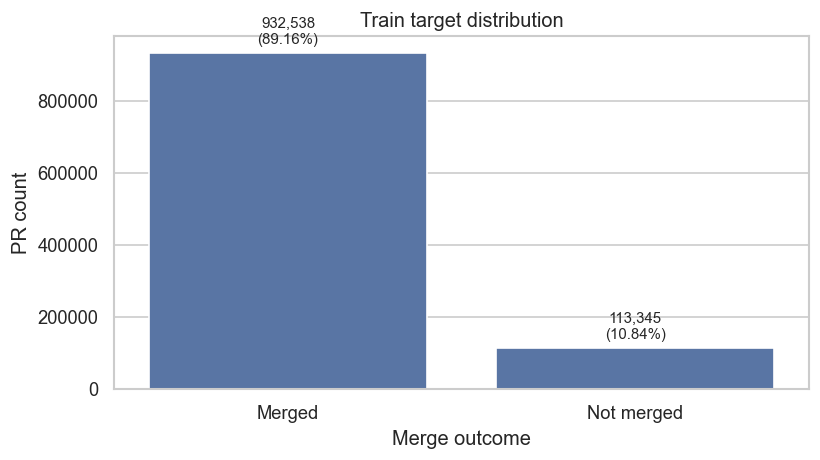


**Interpretation.** Train and test are schema-consistent, both include `merged_or_not`, and the target is encoded as binary values [0, 1].
The class distribution is strongly imbalanced: the train split contains 932,538 merged PRs (89.16%) and 113,345 not-merged PRs (10.84%).
The test split mirrors that balance closely, which supports using it later as a consistent holdout.

**Data-quality note.** The explicit null audit found zero missing values in both train and test. Duplicate row counts are 0 in train and 0 in test.
Zero explicit missing values do not guarantee semantic completeness, valid timestamps, or the absence of hidden sentinel conventions.
TODO for later checkpoints: revisit semantic completeness and value plausibility if downstream preprocessing surfaces suspicious ranges or encodings.


In [8]:
# Schema and target audit
train_dtypes = train_df.dtypes.astype(str)
test_dtypes = test_df.dtypes.astype(str)
all_columns = pd.Index(sorted(set(train_columns).union(test_columns)), name="column")

schema_audit = pd.DataFrame(index=all_columns)
schema_audit["in_train"] = schema_audit.index.isin(train_columns)
schema_audit["in_test"] = schema_audit.index.isin(test_columns)
schema_audit["train_dtype"] = [train_dtypes.get(column) for column in schema_audit.index]
schema_audit["test_dtype"] = [test_dtypes.get(column) for column in schema_audit.index]
schema_audit["dtype_match"] = (
    schema_audit["in_train"]
    & schema_audit["in_test"]
    & (schema_audit["train_dtype"] == schema_audit["test_dtype"])
)

same_column_names = set(train_columns) == set(test_columns)
same_column_order = train_columns.equals(test_columns)
schema_issues = schema_audit[
    (~schema_audit["in_train"])
    | (~schema_audit["in_test"])
    | (~schema_audit["dtype_match"] & schema_audit["in_train"] & schema_audit["in_test"])
]

schema_summary = pd.DataFrame(
    [
        {"check": "train shape", "result": str(train_df.shape)},
        {"check": "test shape", "result": str(test_df.shape)},
        {"check": "train column count", "result": int(train_df.shape[1])},
        {"check": "test column count", "result": int(test_df.shape[1])},
        {"check": "same column names", "result": same_column_names},
        {"check": "same column order", "result": same_column_order},
        {"check": "schema mismatch rows", "result": int(len(schema_issues))},
        {"check": "target present in train", "result": TARGET_COLUMN in train_columns},
        {"check": "target present in test", "result": TARGET_COLUMN in test_columns},
    ]
)

dtype_summary = pd.DataFrame(
    {
        "train_count": train_dtypes.value_counts(),
        "test_count": test_dtypes.value_counts(),
    }
).fillna(0).astype(int)

readable_schema_summary = pd.DataFrame(
    {
        "column": all_columns,
        "train_dtype": [train_dtypes.get(column) for column in all_columns],
        "test_dtype": [test_dtypes.get(column) for column in all_columns],
        "train_non_null": train_df.notna().sum().reindex(all_columns).astype(int).values,
        "test_non_null": test_df.notna().sum().reindex(all_columns).astype(int).values,
        "train_null_count": train_df.isna().sum().reindex(all_columns).astype(int).values,
        "test_null_count": test_df.isna().sum().reindex(all_columns).astype(int).values,
        "train_nunique": train_df.nunique(dropna=True).reindex(all_columns).astype(int).values,
        "test_nunique": test_df.nunique(dropna=True).reindex(all_columns).astype(int).values,
        "dtype_match": schema_audit.reindex(all_columns)["dtype_match"].values,
    }
)

def build_broad_summary(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    summary = df.describe(include="all").transpose()
    preferred_columns = ["count", "unique", "top", "freq", "mean", "std", "min", "25%", "50%", "75%", "max"]
    available_columns = [column for column in preferred_columns if column in summary.columns]
    return (
        summary[available_columns]
        .reset_index()
        .rename(columns={"index": "column"})
        .assign(split=split_name)
        [["split", "column", *available_columns]]
    )

train_broad_summary = build_broad_summary(train_df, "train")
test_broad_summary = build_broad_summary(test_df, "test")

null_summary = (
    pd.DataFrame(
        {
            "train_null_count": train_df.isna().sum(),
            "test_null_count": test_df.isna().sum(),
        }
    )
    .fillna(0)
    .astype(int)
    .reset_index()
    .rename(columns={"index": "column"})
)
null_summary["any_nulls"] = (null_summary["train_null_count"] > 0) | (null_summary["test_null_count"] > 0)

train_total_nulls = int(null_summary["train_null_count"].sum())
test_total_nulls = int(null_summary["test_null_count"].sum())
train_null_columns = int((null_summary["train_null_count"] > 0).sum())
test_null_columns = int((null_summary["test_null_count"] > 0).sum())

train_duplicate_rows = int(train_df.duplicated().sum())
test_duplicate_rows = int(test_df.duplicated().sum())
duplicate_summary = pd.DataFrame(
    [
        {"split": "train", "duplicate_row_count": train_duplicate_rows},
        {"split": "test", "duplicate_row_count": test_duplicate_rows},
    ]
)

explicit_missing_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "total_explicit_nulls": train_total_nulls,
            "columns_with_nulls": train_null_columns,
            "zero_explicit_missing_values": train_total_nulls == 0,
        },
        {
            "split": "test",
            "total_explicit_nulls": test_total_nulls,
            "columns_with_nulls": test_null_columns,
            "zero_explicit_missing_values": test_total_nulls == 0,
        },
    ]
)

if train_total_nulls == 0 and test_total_nulls == 0:
    missingness_note = "The explicit null audit found zero missing values in both train and test."
else:
    missingness_note = (
        f"The explicit null audit found {train_total_nulls:,} null values in train and {test_total_nulls:,} null values in test."
    )

def build_target_distribution(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    counts = df[TARGET_COLUMN].value_counts().sort_index()
    percentages = (counts / len(df) * 100).round(2)
    return pd.DataFrame(
        {
            "split": split_name,
            "target_value": counts.index,
            "label": [TARGET_LABELS[value] for value in counts.index],
            "count": counts.values,
            "percentage": percentages.values,
        }
    )

target_distribution_train = build_target_distribution(train_df, "train")
target_distribution_test = build_target_distribution(test_df, "test")
target_comparison = pd.concat([target_distribution_train, target_distribution_test], ignore_index=True)

target_audit = {
    "target_column": TARGET_COLUMN,
    "target_in_train": TARGET_COLUMN in train_columns,
    "target_in_test": TARGET_COLUMN in test_columns,
    "train_target_missing": int(train_df[TARGET_COLUMN].isna().sum()),
    "test_target_missing": int(test_df[TARGET_COLUMN].isna().sum()),
    "train_target_values": sorted(train_df[TARGET_COLUMN].dropna().unique().tolist()),
    "test_target_values": sorted(test_df[TARGET_COLUMN].dropna().unique().tolist()),
}

display(Markdown("""
**Checkpoint 1 audit note.** This section makes dataset structure, target availability, explicit missingness, duplicate rows, and broad summaries visible before any later modelling work. At this checkpoint, the goal is understanding and auditability rather than prediction.
"""))
display(schema_summary)
display(dtype_summary)
display(Markdown("**Readable schema summary.** The table below is a compact equivalent of a `df.info()`-style schema view for both splits."))
display(readable_schema_summary)
display(Markdown("**Broad summary for the training split.** Readable equivalent of `describe(include='all')`."))
display(train_broad_summary)
display(Markdown("**Broad summary for the test split.** This is shown only for consistency checking at Checkpoint 1."))
display(test_broad_summary)
display(Markdown("**Explicit null counts per column.**"))
display(null_summary)
display(Markdown("**Duplicate row counts.**"))
display(duplicate_summary)
display(Markdown("**Explicit missing-value summary.**"))
display(explicit_missing_summary)
if schema_issues.empty:
    display(Markdown("**Schema check.** No train/test schema mismatches were detected."))
else:
    display(schema_issues)

display(target_comparison)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=target_distribution_train, x="label", y="count", order=["Merged", "Not merged"], ax=ax)
ax.set_title("Train target distribution")
ax.set_xlabel("Merge outcome")
ax.set_ylabel("PR count")
for patch, (_, row) in zip(ax.patches, target_distribution_train.set_index("label").loc[["Merged", "Not merged"]].reset_index().iterrows()):
    ax.annotate(
        f"{int(row['count']):,}\n({row['percentage']:.2f}%)",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        fontsize=9,
        xytext=(0, 4),
        textcoords="offset points",
    )
plt.tight_layout()
plt.show()

train_merged_row = target_distribution_train.loc[target_distribution_train["target_value"] == 1].iloc[0]
train_not_merged_row = target_distribution_train.loc[target_distribution_train["target_value"] == 0].iloc[0]

display(Markdown(f"""
**Interpretation.** Train and test are schema-consistent, both include `{TARGET_COLUMN}`, and the target is encoded as binary values {target_audit['train_target_values']}.
The class distribution is strongly imbalanced: the train split contains {int(train_merged_row['count']):,} merged PRs ({train_merged_row['percentage']:.2f}%) and {int(train_not_merged_row['count']):,} not-merged PRs ({train_not_merged_row['percentage']:.2f}%).
The test split mirrors that balance closely, which supports using it later as a consistent holdout.

**Data-quality note.** {missingness_note} Duplicate row counts are {train_duplicate_rows:,} in train and {test_duplicate_rows:,} in test.
Zero explicit missing values do not guarantee semantic completeness, valid timestamps, or the absence of hidden sentinel conventions.
TODO for later checkpoints: revisit semantic completeness and value plausibility if downstream preprocessing surfaces suspicious ranges or encodings.
"""))


## 5. Feature-risk review

This section is for a leakage-aware review of candidate predictors. The focus is to keep a clear separation between identifiers or metadata, clear post-outcome or leakage features, ambiguous features that remain under review, and candidate safe features for early analysis.

In [8]:
# Leakage-aware feature-risk review
status_priority = ["target", "exclude_id", "exclude_post_outcome", "ambiguous", "candidate_safe"]

status_reason_map = {
    "target": "Locked prediction target for the project.",
    "exclude_id": "Identifier or entity key; useful for joins only and not suitable as a predictor.",
    "exclude_post_outcome": "Clearly depends on post-outcome or closure information and would leak future knowledge.",
    "ambiguous": "Potentially influenced by review discussion, interaction, CI progression, or other timing-sensitive events; kept under review for Checkpoint 1.",
    "candidate_safe": "Plausibly available before the final merge decision and conservative enough for Checkpoint 1 descriptive analysis.",
}

post_outcome_reason_override = {
    "last_close_time": "Recorded at or after PR closure, so it depends on the final outcome timeline.",
    "lifetime_minutes": "Measures the PR lifetime, which is only fully known after the PR closes.",
    "reopen_or_not": "Captures post-decision behavior and is not safely available at prediction time.",
}

safe_reason_override = {
    "language": "Encoded project language category; treat as nominal rather than ordinal in EDA.",
}

ambiguous_reason_override = {
    "integrator_availability": "Potentially evolves during the review process and is not obviously fixed at PR creation time.",
}

all_known_features = set([TARGET_COLUMN, *exclude_ids, *exclude_post_outcome, *ambiguous_features, *candidate_safe_features])
uncategorized_features = sorted(set(train_columns) - all_known_features)
if uncategorized_features:
    raise ValueError(f"The following columns are still uncategorized: {uncategorized_features}")


def infer_type_guess(feature_name: str) -> str:
    series = train_df[feature_name]
    nunique = int(series.nunique(dropna=True))
    if feature_name == TARGET_COLUMN:
        return "binary_target"
    if feature_name in exclude_ids:
        return "identifier"
    if feature_name == "last_close_time":
        return "post_outcome_timestamp"
    if feature_name == "language":
        return "categorical_encoded"
    if nunique == 2:
        return "binary_flag"
    if pd.api.types.is_float_dtype(series):
        return "continuous_ratio"
    return "count_or_size"


records = []
for feature_name in train_columns:
    if feature_name == TARGET_COLUMN:
        status = "target"
    elif feature_name in exclude_ids:
        status = "exclude_id"
    elif feature_name in exclude_post_outcome:
        status = "exclude_post_outcome"
    elif feature_name in ambiguous_features:
        status = "ambiguous"
    elif feature_name in candidate_safe_features:
        status = "candidate_safe"
    else:
        status = "uncategorized"

    reason = status_reason_map.get(status, "")
    if feature_name in post_outcome_reason_override:
        reason = post_outcome_reason_override[feature_name]
    if feature_name in safe_reason_override:
        reason = safe_reason_override[feature_name]
    if feature_name in ambiguous_reason_override:
        reason = ambiguous_reason_override[feature_name]

    records.append(
        {
            "feature_name": feature_name,
            "status": status,
            "type_guess": infer_type_guess(feature_name),
            "reason": reason,
        }
    )

feature_risk_review = pd.DataFrame(records)
feature_risk_review["status"] = pd.Categorical(feature_risk_review["status"], categories=status_priority, ordered=True)
feature_risk_review = feature_risk_review.sort_values(["status", "feature_name"]).reset_index(drop=True)
feature_status_counts = (
    feature_risk_review["status"]
    .value_counts(dropna=False)
    .rename_axis("status")
    .reset_index(name="feature_count")
    .sort_values("status")
    .reset_index(drop=True)
)

feature_group_labels = pd.DataFrame(
    [
        {
            "group": "Identifiers / metadata",
            "count": len(exclude_ids),
            "checkpoint_1_use": "Excluded",
            "note": "Entity keys and metadata fields; retained only for reference, not for prediction.",
        },
        {
            "group": "Clear post-outcome or leakage features",
            "count": len(exclude_post_outcome),
            "checkpoint_1_use": "Excluded",
            "note": "Depend on closure or post-decision information and would leak future knowledge.",
        },
        {
            "group": "Ambiguous / under review",
            "count": len(ambiguous_features),
            "checkpoint_1_use": "Held back",
            "note": "Timing relative to the merge decision is not yet sufficiently justified.",
        },
        {
            "group": "Candidate safe features",
            "count": len(candidate_safe_features),
            "checkpoint_1_use": "Allowed for descriptive EDA",
            "note": "Conservative set judged plausibly available before the final merge decision.",
        },
    ]
)

display(Markdown("""
**Feature-risk framing.** The notebook keeps a strict separation between identifiers or metadata, clear post-outcome or leakage features, ambiguous under-review variables, and candidate safe features. Ambiguous features remain under review because their timing relative to the merge decision is not yet clear enough for Checkpoint 1.
"""))
display(feature_group_labels)
display(feature_status_counts)
display(feature_risk_review)
display(Markdown(f"""
**Interpretation.** The current Checkpoint 1 framing separates {len(exclude_ids)} identifier fields, {len(exclude_post_outcome)} clearly unsafe post-outcome fields, {len(ambiguous_features)} timing-sensitive fields kept under review, and {len(candidate_safe_features)} conservative candidate-safe fields for early EDA.
`language` is retained only as a categorical encoded feature and must not be treated as ordinal.
TODO for Checkpoint 2: revisit only the under-review features whose timing can be justified explicitly.
"""))



**Feature-risk framing.** The notebook keeps a strict separation between identifiers or metadata, clear post-outcome or leakage features, ambiguous under-review variables, and candidate safe features. Ambiguous features remain under review because their timing relative to the merge decision is not yet clear enough for Checkpoint 1.


,group,count,checkpoint_1_use,note
0,Identifiers / metadata,4,Excluded,Entity keys and metadata fields; retained only...
1,Clear post-outcome or leakage features,3,Excluded,Depend on closure or post-decision information...
2,Ambiguous / under review,32,Held back,Timing relative to the merge decision is not y...
3,Candidate safe features,32,Allowed for descriptive EDA,Conservative set judged plausibly available be...


,status,feature_count
0,target,1
1,exclude_id,4
2,exclude_post_outcome,3
3,ambiguous,32
4,candidate_safe,32


,feature_name,status,type_guess,reason
0,merged_or_not,target,binary_target,Locked prediction target for the project.
1,creator_id,exclude_id,identifier,Identifier or entity key; useful for joins onl...
2,id,exclude_id,identifier,Identifier or entity key; useful for joins onl...
3,last_closer_id,exclude_id,identifier,Identifier or entity key; useful for joins onl...
4,project_id,exclude_id,identifier,Identifier or entity key; useful for joins onl...
5,last_close_time,exclude_post_outcome,post_outcome_timestamp,"Recorded at or after PR closure, so it depends..."
6,lifetime_minutes,exclude_post_outcome,count_or_size,"Measures the PR lifetime, which is only fully ..."
7,reopen_or_not,exclude_post_outcome,binary_flag,Captures post-decision behavior and is not saf...
8,at_tag,ambiguous,binary_flag,"Potentially influenced by review discussion, i..."
9,ci_build_num,ambiguous,count_or_size,"Potentially influenced by review discussion, i..."



**Interpretation.** The current Checkpoint 1 framing separates 4 identifier fields, 3 clearly unsafe post-outcome fields, 32 timing-sensitive fields kept under review, and 32 conservative candidate-safe fields for early EDA.
`language` is retained only as a categorical encoded feature and must not be treated as ordinal.
TODO for Checkpoint 2: revisit only the under-review features whose timing can be justified explicitly.


## 6. Safe feature shortlist

This section captures the features judged safe enough for Checkpoint 1 summaries and early EDA. The shortlist remains conservative by design, and `language` must be treated as categorical rather than ordinal.

In [9]:
# Safe feature shortlist for conservative Checkpoint 1 EDA
missing_safe_features = sorted(set(candidate_safe_features) - set(train_columns))
if missing_safe_features:
    raise ValueError(f"Candidate safe features missing from the training data: {missing_safe_features}")

final_safe_eda_features = candidate_safe_features.copy()
safe_feature_df = train_df[final_safe_eda_features].copy()


def infer_logical_role(feature_name: str) -> str:
    series = safe_feature_df[feature_name]
    nunique = int(series.nunique(dropna=True))
    if feature_name == "language":
        return "categorical_encoded"
    if nunique == 2:
        return "binary_flag"
    if pd.api.types.is_float_dtype(series):
        return "rate_or_continuous"
    return "count_or_size"


safe_feature_profile = []
for feature_name in final_safe_eda_features:
    series = safe_feature_df[feature_name]
    safe_feature_profile.append(
        {
            "feature_name": feature_name,
            "dtype": str(series.dtype),
            "logical_role": infer_logical_role(feature_name),
            "nunique": int(series.nunique(dropna=True)),
            "min": float(series.min()),
            "p01": float(series.quantile(0.01)),
            "median": float(series.median()),
            "p99": float(series.quantile(0.99)),
            "max": float(series.max()),
        }
    )

safe_feature_profile = pd.DataFrame(safe_feature_profile).sort_values(["logical_role", "feature_name"]).reset_index(drop=True)
safe_feature_summary = {
    "num_final_safe_features": len(final_safe_eda_features),
    "num_binary_safe_features": int((safe_feature_profile["logical_role"] == "binary_flag").sum()),
    "num_categorical_safe_features": int((safe_feature_profile["logical_role"] == "categorical_encoded").sum()),
    "num_numeric_safe_features": int((safe_feature_profile["logical_role"] != "binary_flag").sum() - (safe_feature_profile["logical_role"] == "categorical_encoded").sum()),
}

safe_numeric_features = safe_feature_profile.loc[
    safe_feature_profile["logical_role"].isin(["count_or_size", "rate_or_continuous"]),
    "feature_name",
].tolist()

high_skew_signal = (
    safe_feature_df[safe_numeric_features]
    .agg(["mean", "median"]).T
    .assign(mean_to_median_ratio=lambda df: np.where(df["median"].abs() > 0, df["mean"] / df["median"], np.nan))
    .sort_values("mean_to_median_ratio", ascending=False)
    .round(3)
)

display(pd.DataFrame([safe_feature_summary]))
display(safe_feature_profile)
display(high_skew_signal.head(10))
display(Markdown(f"""
**Checkpoint 1 shortlist.** After checking data types, unique counts, and broad ranges, the notebook keeps {len(final_safe_eda_features)} conservative features for initial EDA.
`language` is retained as a categorical encoded feature and must be interpreted as nominal rather than ordinal.
Features listed as ambiguous remain under review and are intentionally excluded from this shortlist until their timing relative to the merge decision is justified more clearly.
The first visual pass focuses on a smaller subset of interpretable safe variables: {', '.join(eda_focus_features)}.
"""))


,num_final_safe_features,num_binary_safe_features,num_categorical_safe_features,num_numeric_safe_features
0,32,5,1,26


,feature_name,dtype,logical_role,nunique,min,p01,median,p99,max
0,ci_exists,int64,binary_flag,2,0.000,0.000,1.000,1.000,1.000
1,core_member,int64,binary_flag,2,0.000,0.000,1.000,1.000,1.000
2,first_pr,int64,binary_flag,2,0.000,0.000,0.000,1.000,1.000
3,friday_effect,int64,binary_flag,2,0.000,0.000,0.000,1.000,1.000
4,test_inclusion,int64,binary_flag,2,0.000,0.000,0.000,1.000,1.000
5,language,int64,categorical_encoded,6,0.000,0.000,2.000,5.000,5.000
6,account_creation_days,int64,count_or_size,4114,0.000,57.000,"1,683.000","3,684.000","4,125.000"
7,churn_addition,int64,count_or_size,13903,0.000,0.000,17.000,"5,901.180","2,962,001.000"
8,churn_deletion,int64,count_or_size,11253,0.000,0.000,5.000,"3,758.000","1,967,331.000"
9,description_length,int64,count_or_size,1820,0.000,2.000,21.000,380.000,"31,223.000"


,mean,median,mean_to_median_ratio
churn_deletion,284.841,5.000,56.968
src_churn,621.983,18.000,34.555
churn_addition,434.895,17.000,25.582
stars,"2,038.996",145.000,14.062
followers,150.362,18.000,8.353
fork_num,564.709,75.000,7.529
files_changed,11.399,2.000,5.700
sloc,"84,551.218","16,973.000",4.982
open_issue_num,169.840,38.000,4.469
open_pr_num,52.656,13.000,4.050



**Checkpoint 1 shortlist.** After checking data types, unique counts, and broad ranges, the notebook keeps 32 conservative features for initial EDA.
`language` is retained as a categorical encoded feature and must be interpreted as nominal rather than ordinal.
Features listed as ambiguous remain under review and are intentionally excluded from this shortlist until their timing relative to the merge decision is justified more clearly.
The first visual pass focuses on a smaller subset of interpretable safe variables: first_pr, core_member, prior_review_num, prev_pullreqs, sloc, team_size, stars, num_commits, files_changed, description_length, churn_addition, churn_deletion, pr_succ_rate, requester_succ_rate, friday_effect, test_inclusion.


## 7. Initial EDA on safe features

This section is reserved for early descriptive analysis on the conservative safe-feature subset only. The restriction exists because identifiers, clear post-outcome variables, and timing-sensitive under-review features could leak future information. Plots and tables added here should support interpretation, not prediction claims.


**Restricted EDA scope.** This section uses only the conservative safe-feature subset selected for Checkpoint 1. The restriction exists because identifier fields, clear post-outcome variables, and timing-sensitive under-review features could leak future information.

No predictive modelling is performed here; the purpose is initial descriptive analysis that supports later feature justification.


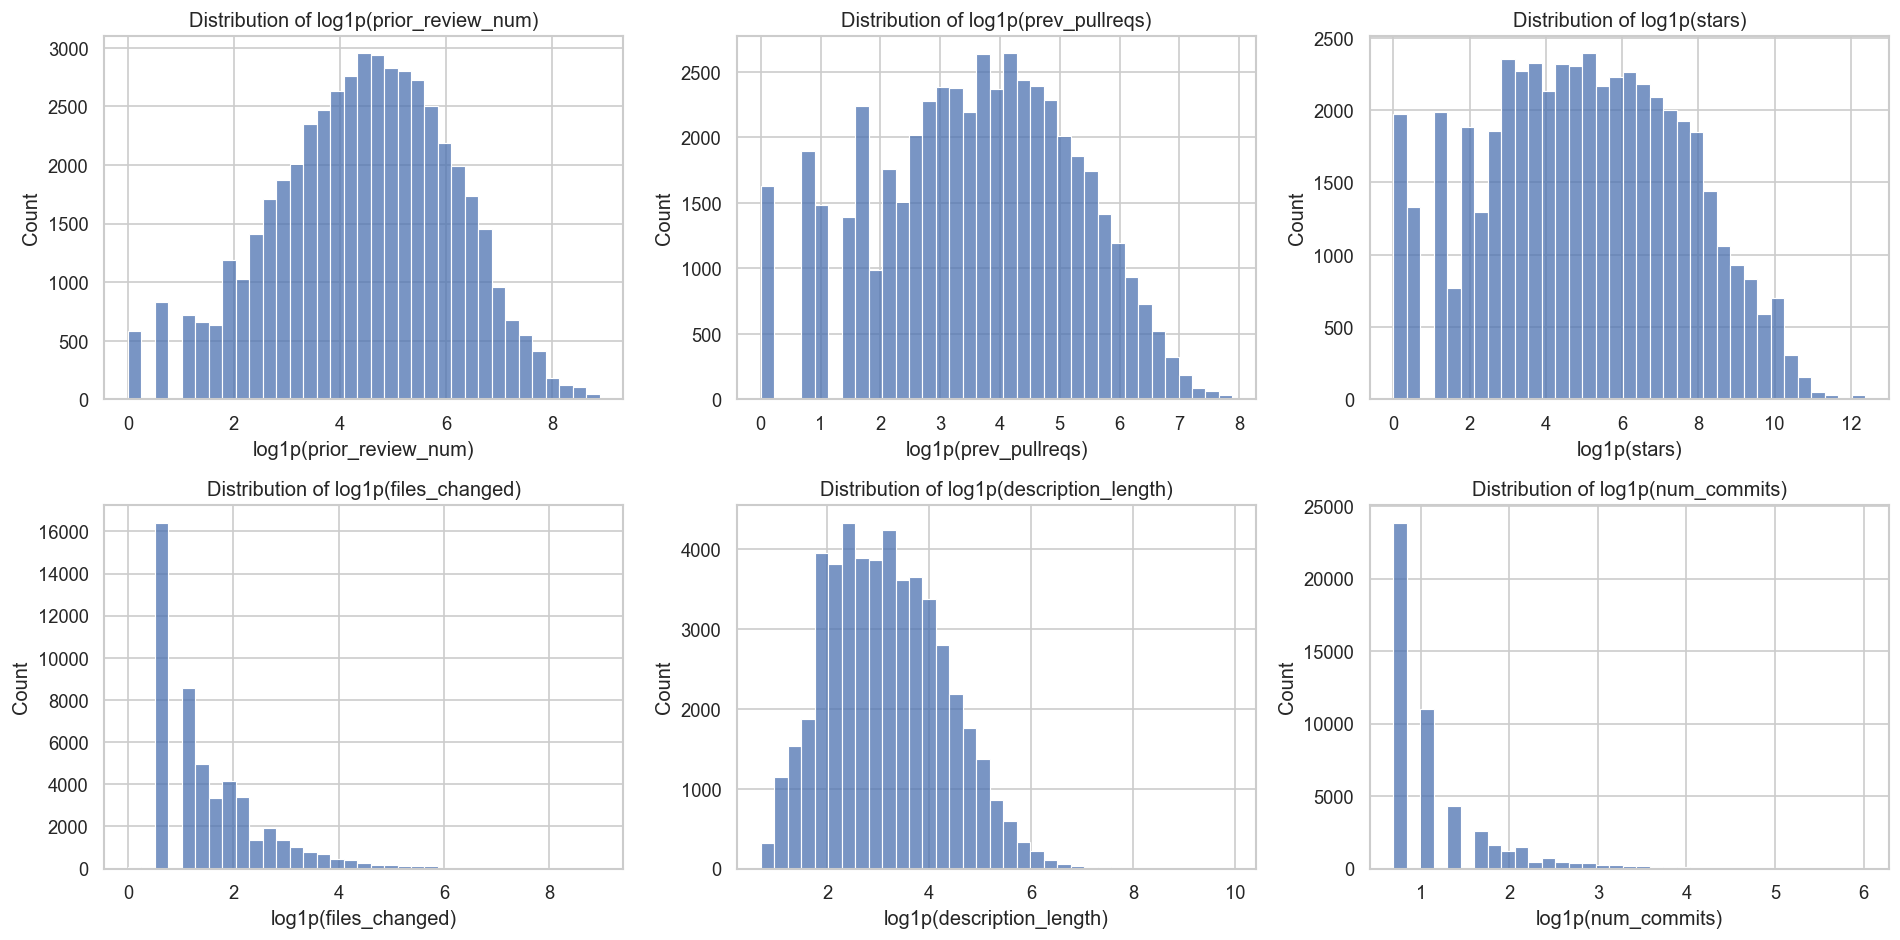

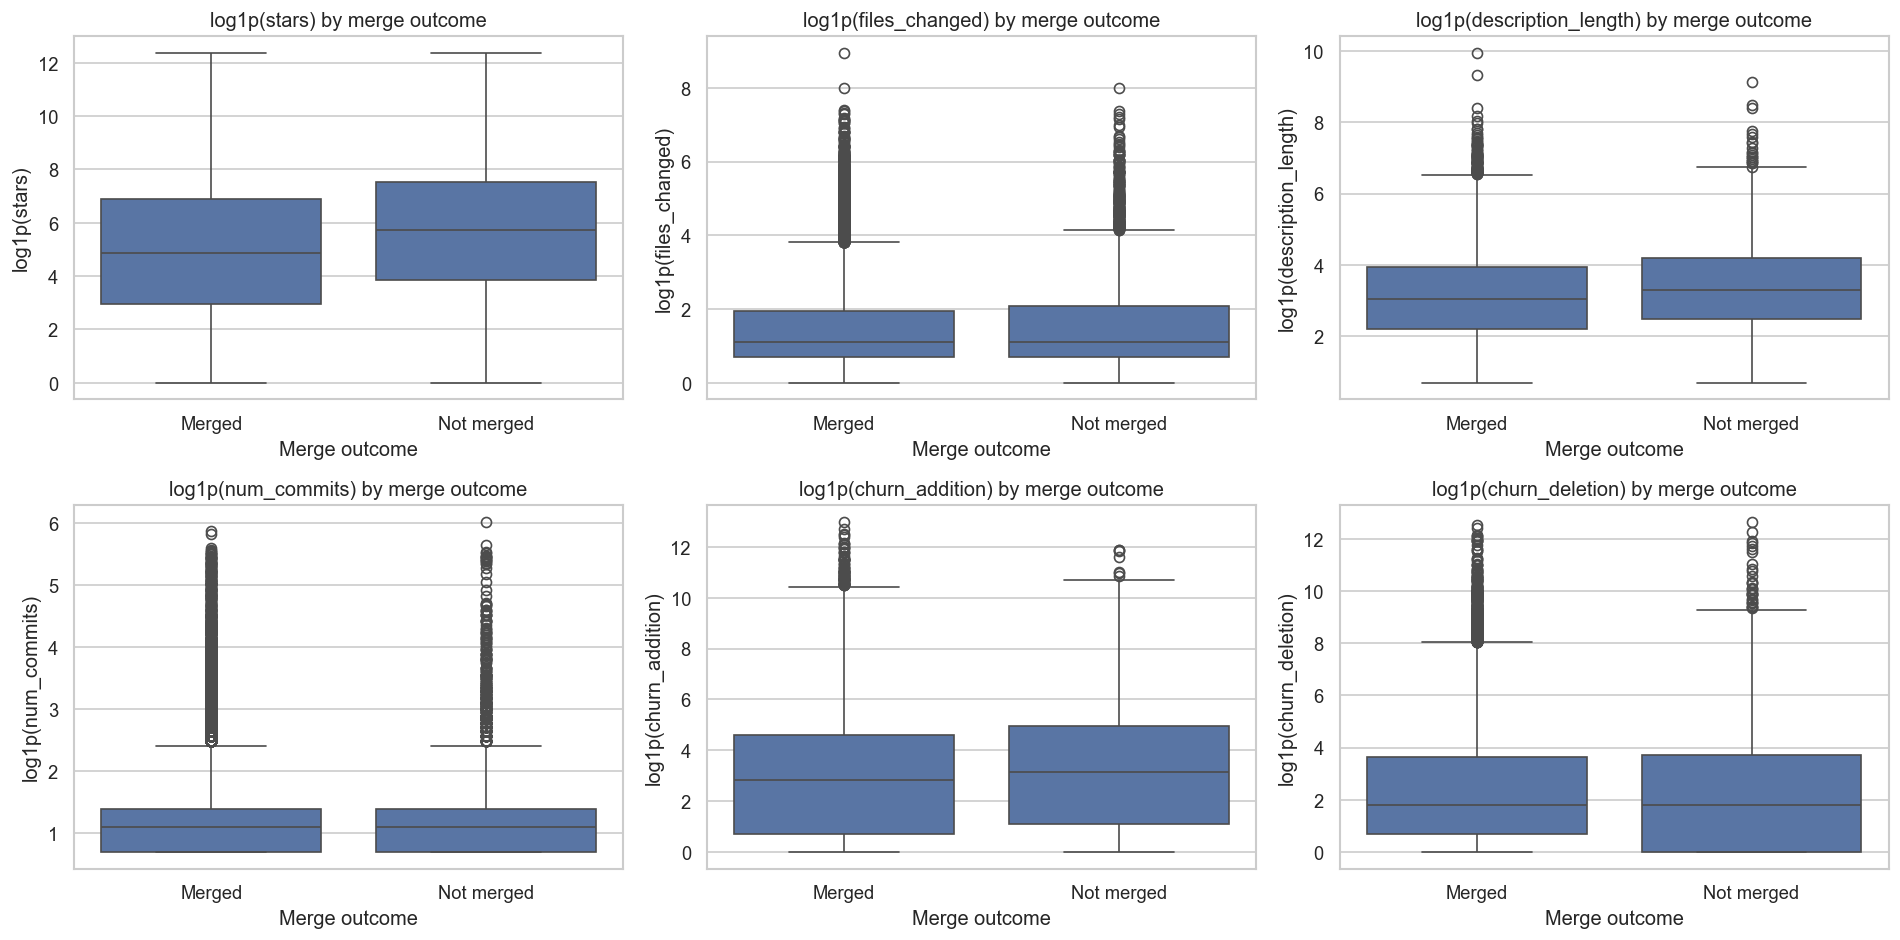

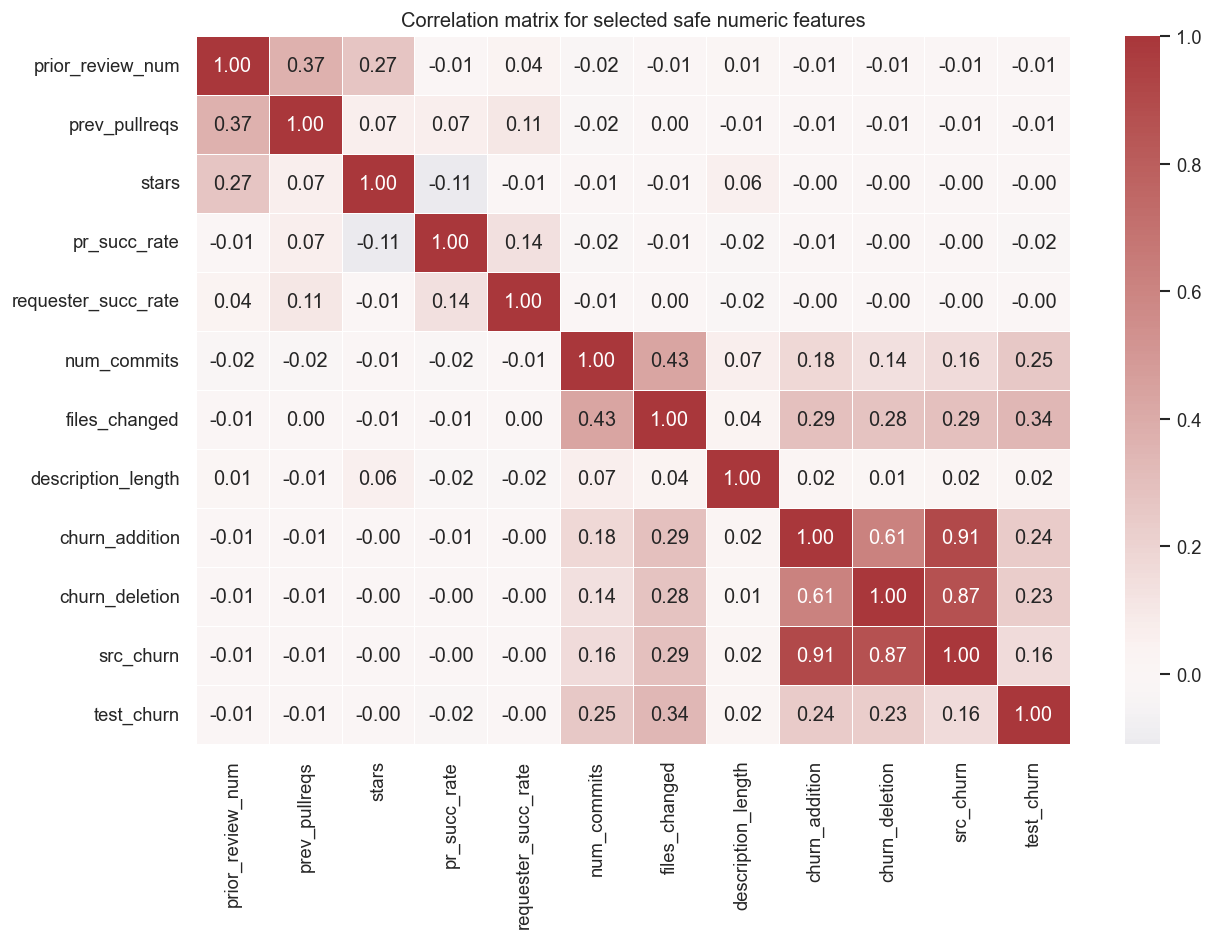

,mean,median,std,min,max,mean_minus_median
prior_review_num,265.719,88.000,526.823,0.000,"15,893.000",177.719
prev_pullreqs,110.666,38.000,194.901,0.000,"3,744.000",72.666
stars,"2,038.996",145.000,"7,582.797",0.000,"238,444.000","1,893.996"
num_commits,4.062,2.000,12.673,1.000,759.000,2.062
files_changed,11.399,2.000,64.497,0.000,"17,328.000",9.399
description_length,47.466,21.000,125.609,0.000,"31,223.000",26.466
churn_addition,434.895,17.000,"7,261.838",0.000,"2,962,001.000",417.895
churn_deletion,284.841,5.000,"5,996.047",0.000,"1,967,331.000",279.841
pr_succ_rate,0.972,0.980,0.035,0.000,1.000,-0.008
requester_succ_rate,0.947,0.999,0.182,0.000,1.000,-0.052


first_pr        core_member        prior_review_num         \
                  mean median        mean median             mean median   
merged_or_not                                                              
0                0.058  0.000       0.682  1.000          205.813 54.000   
1                0.029  0.000       0.817  1.000          273.000 93.000   

              prev_pullreqs               sloc            team_size         \
                       mean median        mean     median      mean median   
merged_or_not                                                                
0                    89.504 22.000 108,532.914 24,914.000    14.308  7.000   
1                   113.238 41.000  81,636.372 16,253.000     9.784  6.000   

                  stars         num_commits        files_changed         \
                   mean  median        mean median          mean median   
merged_or_not                                                             
0             3,083.394 289.000       4.696  2.000        15.441  2.000   
1             1,912.055 130.000       3.984  2.000        10.908  2.000   

              description_length        churn_addition        churn_deletion  \
                            mean median           mean median           mean   
merged_or_not                                                                  
0                         59.919 26.000        618.555 22.000        344.610   
1                         45.953 20.000        412.572 16.000        277.576   

                     pr_succ_rate        requester_succ_rate         \
              median         mean median                mean median   
merged_or_not                                                         
0              5.000        0.964  0.974               0.917  1.000   
1              5.000        0.973  0.980               0.951  0.998   

              friday_effect        test_inclusion         
                       mean median           mean median  
merged_or_not                                             
0                     0.162  0.000          0.230  0.000  
1                     0.167  0.000          0.208  0.000

,feature,value,count,merge_rate_pct
0,first_pr,0,1012149,89.450
1,first_pr,1,33734,80.680
2,core_member,0,206724,82.560
3,core_member,1,839159,90.790
4,test_inclusion,0,825940,89.430
5,test_inclusion,1,219943,88.170
6,friday_effect,0,872033,89.110
7,friday_effect,1,173850,89.420


merged_or_not,Not merged,Merged
language,,
0,0.093,0.907
1,0.140,0.860
2,0.101,0.899
3,0.100,0.900
4,0.101,0.899
5,0.106,0.894



**EDA note.** Summary tables use the full training dataset, while the histogram and boxplot panels use a random sample of 50,000 PRs to keep plotting responsive in VS Code and Colab.
`language` is shown as a categorical encoded variable only; its numeric codes must not be interpreted as ordinal ranking.


In [10]:
# Initial EDA on the conservative safe-feature subset
display(Markdown(f"""
**Restricted EDA scope.** This section uses only the conservative safe-feature subset selected for Checkpoint 1. The restriction exists because identifier fields, clear post-outcome variables, and timing-sensitive under-review features could leak future information.

No predictive modelling is performed here; the purpose is initial descriptive analysis that supports later feature justification.
"""))

plot_sample = train_df[sorted(set(eda_focus_features + ["src_churn", "test_churn", TARGET_COLUMN]))].sample(
    n=min(EDA_PLOT_SAMPLE, len(train_df)),
    random_state=RANDOM_STATE,
).copy()
plot_sample["merge_label"] = plot_sample[TARGET_COLUMN].map(TARGET_LABELS)

selected_numeric_features = [
    "prior_review_num",
    "prev_pullreqs",
    "stars",
    "num_commits",
    "files_changed",
    "description_length",
    "churn_addition",
    "churn_deletion",
    "pr_succ_rate",
    "requester_succ_rate",
]

safe_numeric_summary = (
    train_df[selected_numeric_features]
    .agg(["mean", "median", "std", "min", "max"]).T
    .assign(mean_minus_median=lambda df: df["mean"] - df["median"])
    .round(3)
)

merged_vs_not_summary = (
    train_df.groupby(TARGET_COLUMN)[eda_focus_features]
    .agg(["mean", "median"])
    .round(3)
)

hist_features = ["prior_review_num", "prev_pullreqs", "stars", "files_changed", "description_length", "num_commits"]
for feature_name in hist_features:
    plot_sample[f"log1p_{feature_name}"] = np.log1p(plot_sample[feature_name])

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, feature_name in zip(axes.flatten(), hist_features):
    sns.histplot(plot_sample, x=f"log1p_{feature_name}", bins=35, ax=ax, color="#4C72B0")
    ax.set_title(f"Distribution of log1p({feature_name})")
    ax.set_xlabel(f"log1p({feature_name})")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

boxplot_features = ["stars", "files_changed", "description_length", "num_commits", "churn_addition", "churn_deletion"]
for feature_name in boxplot_features:
    plot_sample[f"log1p_{feature_name}"] = np.log1p(plot_sample[feature_name])

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, feature_name in zip(axes.flatten(), boxplot_features):
    sns.boxplot(data=plot_sample, x="merge_label", y=f"log1p_{feature_name}", order=["Merged", "Not merged"], ax=ax)
    ax.set_title(f"log1p({feature_name}) by merge outcome")
    ax.set_xlabel("Merge outcome")
    ax.set_ylabel(f"log1p({feature_name})")
plt.tight_layout()
plt.show()

correlation_features = [
    "prior_review_num",
    "prev_pullreqs",
    "stars",
    "pr_succ_rate",
    "requester_succ_rate",
    "num_commits",
    "files_changed",
    "description_length",
    "churn_addition",
    "churn_deletion",
    "src_churn",
    "test_churn",
]
correlation_matrix = train_df[correlation_features].corr(numeric_only=True).round(2)

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(correlation_matrix, cmap="vlag", center=0, annot=True, fmt=".2f", linewidths=0.5, ax=ax)
ax.set_title("Correlation matrix for selected safe numeric features")
plt.tight_layout()
plt.show()

categorical_context_features = ["first_pr", "core_member", "test_inclusion", "friday_effect"]
context_merge_rate_table = pd.concat(
    [
        train_df.groupby(feature_name)[TARGET_COLUMN]
        .agg(merge_rate="mean", count="size")
        .reset_index()
        .rename(columns={feature_name: "value"})
        .assign(feature=feature_name, merge_rate_pct=lambda df: (df["merge_rate"] * 100).round(2))
        for feature_name in categorical_context_features
    ],
    ignore_index=True,
)[["feature", "value", "count", "merge_rate_pct"]]

language_target_share = (
    pd.crosstab(train_df["language"], train_df[TARGET_COLUMN], normalize="index")
    .rename(columns=TARGET_LABELS)
    .round(3)
)

display(safe_numeric_summary)
display(merged_vs_not_summary)
display(context_merge_rate_table)
display(language_target_share)
display(Markdown(f"""
**EDA note.** Summary tables use the full training dataset, while the histogram and boxplot panels use a random sample of {min(EDA_PLOT_SAMPLE, len(train_df)):,} PRs to keep plotting responsive in VS Code and Colab.
`language` is shown as a categorical encoded variable only; its numeric codes must not be interpreted as ordinal ranking.
"""))


## 8. Key findings for Checkpoint 1

This section stores concise evidence-based conclusions after the audit and first EDA pass are complete. It does not include predictive modelling results, unsupported interpretations, or model-oriented claims.

In [11]:
# Checkpoint-ready findings based on the current audit and EDA
train_merged_pct = target_distribution_train.loc[target_distribution_train["target_value"] == 1, "percentage"].iloc[0]
train_not_merged_pct = target_distribution_train.loc[target_distribution_train["target_value"] == 0, "percentage"].iloc[0]

first_pr_merge_rate = context_merge_rate_table.query("feature == 'first_pr' and value == 1")["merge_rate_pct"].iloc[0]
repeat_pr_merge_rate = context_merge_rate_table.query("feature == 'first_pr' and value == 0")["merge_rate_pct"].iloc[0]
core_member_merge_rate = context_merge_rate_table.query("feature == 'core_member' and value == 1")["merge_rate_pct"].iloc[0]
non_core_member_merge_rate = context_merge_rate_table.query("feature == 'core_member' and value == 0")["merge_rate_pct"].iloc[0]

files_changed_not_merged_mean = merged_vs_not_summary.loc[0, ("files_changed", "mean")]
files_changed_merged_mean = merged_vs_not_summary.loc[1, ("files_changed", "mean")]
churn_addition_not_merged_mean = merged_vs_not_summary.loc[0, ("churn_addition", "mean")]
churn_addition_merged_mean = merged_vs_not_summary.loc[1, ("churn_addition", "mean")]
description_not_merged_mean = merged_vs_not_summary.loc[0, ("description_length", "mean")]
description_merged_mean = merged_vs_not_summary.loc[1, ("description_length", "mean")]

checkpoint1_findings = {
    "target_and_scope": [
        "The notebook stays within the locked Checkpoint 1 scope: PRFeatures train as the main dataset, PRFeatures test only for consistency checks, and merged_or_not as the target.",
        "No predictive modelling is performed yet; Checkpoint 1 is limited to problem understanding, target audit, data quality, leakage awareness, and initial EDA.",
        f"The target is strongly imbalanced in train ({train_merged_pct:.2f}% merged vs {train_not_merged_pct:.2f}% not merged), so later modeling must use imbalance-aware evaluation.",
    ],
    "schema_observations": [
        "Train and test contain the same 72 columns in the same order, and no schema mismatches were found.",
        f"The target is present in both splits with binary values {target_audit['train_target_values']} and no missing values in either split.",
    ],
    "data_quality_observations": [
        missingness_note,
        f"Duplicate row counts are {train_duplicate_rows:,} in train and {test_duplicate_rows:,} in test; this supports a clean initial audit but does not guarantee semantic completeness.",
    ],
    "feature_risk_observations": [
        f"The current checkpoint split uses 4 identifier features, 3 clearly unsafe post-outcome features, 32 ambiguous timing-sensitive features, and 32 conservative candidate-safe features.",
        "Review-discussion, interaction, and CI-progress features remain under review rather than being used aggressively in the first checkpoint, and `language` is treated as categorical rather than ordinal.",
    ],
    "eda_observations": [
        "EDA is deliberately restricted to the conservative safe subset because the other feature groups may leak future information or require stronger timing justification.",
        "Many safe numeric features are heavily right-skewed, with means noticeably above medians for project size and code-change metrics such as stars, sloc, churn, and files changed.",
        f"Non-merged PRs are larger on average than merged PRs in several safe dimensions, including files_changed ({files_changed_not_merged_mean:.2f} vs {files_changed_merged_mean:.2f}), churn_addition ({churn_addition_not_merged_mean:.2f} vs {churn_addition_merged_mean:.2f}), and description_length ({description_not_merged_mean:.2f} vs {description_merged_mean:.2f}).",
        f"Contributor context also differs: first-time PRs show a lower merge share than repeat PRs ({first_pr_merge_rate:.2f}% vs {repeat_pr_merge_rate:.2f}%), and non-core-member PRs merge less often than core-member PRs ({non_core_member_merge_rate:.2f}% vs {core_member_merge_rate:.2f}%).",
    ],
    "limitations": [
        "These findings are descriptive and associative only; they do not support causal claims.",
        "Several potentially informative review and interaction features remain under review because their timing relative to the merge decision is unclear.",
    ],
}

display(Markdown(f"""
**Checkpoint 1 findings.**
- No predictive modelling is performed yet; this checkpoint is focused on problem understanding, target audit, data quality, leakage awareness, and initial EDA.
- The PRFeatures train/test splits are schema-consistent and both contain the locked binary target `merged_or_not`.
- {missingness_note} Duplicate row counts are {train_duplicate_rows:,} in train and {test_duplicate_rows:,} in test.
- The target is strongly imbalanced: {train_merged_pct:.2f}% merged versus {train_not_merged_pct:.2f}% not merged in the training split.
- Leakage control is central to the project framing: 4 identifier fields and 3 clearly post-outcome fields are excluded immediately, while 32 timing-sensitive fields remain under review and `language` is treated as categorical rather than ordinal.
- EDA is restricted to the conservative safe subset, and safe numeric features are strongly skewed and outlier-prone, especially project-scale and change-size variables.
- In the first safe-feature pass, non-merged PRs tend to be larger, and first-time or non-core-member contributions show lower merge rates.
"""))

checkpoint1_findings



**Checkpoint 1 findings.**
- No predictive modelling is performed yet; this checkpoint is focused on problem understanding, target audit, data quality, leakage awareness, and initial EDA.
- The PRFeatures train/test splits are schema-consistent and both contain the locked binary target `merged_or_not`.
- The explicit null audit found zero missing values in both train and test. Duplicate row counts are 0 in train and 0 in test.
- The target is strongly imbalanced: 89.16% merged versus 10.84% not merged in the training split.
- Leakage control is central to the project framing: 4 identifier fields and 3 clearly post-outcome fields are excluded immediately, while 32 timing-sensitive fields remain under review and `language` is treated as categorical rather than ordinal.
- EDA is restricted to the conservative safe subset, and safe numeric features are strongly skewed and outlier-prone, especially project-scale and change-size variables.
- In the first safe-feature pass, non-merged PRs tend to be larger, and first-time or non-core-member contributions show lower merge rates.


{'target_and_scope': ['The notebook stays within the locked Checkpoint 1 scope: PRFeatures train as the main dataset, PRFeatures test only for consistency checks, and merged_or_not as the target.',
  'No predictive modelling is performed yet; Checkpoint 1 is limited to problem understanding, target audit, data quality, leakage awareness, and initial EDA.',
  'The target is strongly imbalanced in train (89.16% merged vs 10.84% not merged), so later modeling must use imbalance-aware evaluation.'],
 'schema_observations': ['Train and test contain the same 72 columns in the same order, and no schema mismatches were found.',
  'The target is present in both splits with binary values [0, 1] and no missing values in either split.'],
 'data_quality_observations': ['The explicit null audit found zero missing values in both train and test.',
  'Duplicate row counts are 0 in train and 0 in test; this supports a clean initial audit but does not guarantee semantic completeness.'],
 'feature_risk_ob

## 9. Next steps for Checkpoint 2

This section should convert Checkpoint 1 observations into concrete follow-up work for preprocessing, feature selection, modeling, evaluation, and documentation in the next milestone.

In [12]:
# Next steps for Checkpoint 2
checkpoint2_next_steps = [
    "Finalize the conservative feature subset and revisit ambiguous review or CI variables only if their timing can be justified clearly.",
    "Build a reproducible preprocessing pipeline that treats binary flags, numeric count or size variables, rate variables, and encoded categorical features consistently.",
    "Use class-imbalance-aware metrics and baselines in Checkpoint 2 instead of relying on raw accuracy alone.",
    "Consider transformations or robust scaling for strongly skewed size-related variables before modeling.",
    "Keep the provided test split untouched for later evaluation and continue doing exploratory work and internal validation on the training split only.",
]

display(Markdown(
    "**Next steps for Checkpoint 2.**\n"
    + "\n".join([f"- {step}" for step in checkpoint2_next_steps])
))

checkpoint2_next_steps


**Next steps for Checkpoint 2.**
- Finalize the conservative feature subset and revisit ambiguous review or CI variables only if their timing can be justified clearly.
- Build a reproducible preprocessing pipeline that treats binary flags, numeric count or size variables, rate variables, and encoded categorical features consistently.
- Use class-imbalance-aware metrics and baselines in Checkpoint 2 instead of relying on raw accuracy alone.
- Consider transformations or robust scaling for strongly skewed size-related variables before modeling.
- Keep the provided test split untouched for later evaluation and continue doing exploratory work and internal validation on the training split only.

['Finalize the conservative feature subset and revisit ambiguous review or CI variables only if their timing can be justified clearly.',
 'Build a reproducible preprocessing pipeline that treats binary flags, numeric count or size variables, rate variables, and encoded categorical features consistently.',
 'Use class-imbalance-aware metrics and baselines in Checkpoint 2 instead of relying on raw accuracy alone.',
 'Consider transformations or robust scaling for strongly skewed size-related variables before modeling.',
 'Keep the provided test split untouched for later evaluation and continue doing exploratory work and internal validation on the training split only.']

## Presentation extraction notes

This section turns the notebook outputs into slide-ready material for the Checkpoint 1 presentation.

In [13]:
# Slide-ready extraction notes
presentation_notes = {
    "slide_3": [
        f"Target variable: `{TARGET_COLUMN}`.",
        f"Train split: {int(target_distribution_train.loc[target_distribution_train['target_value'] == 1, 'count'].iloc[0]):,} merged PRs ({target_distribution_train.loc[target_distribution_train['target_value'] == 1, 'percentage'].iloc[0]:.2f}%) and {int(target_distribution_train.loc[target_distribution_train['target_value'] == 0, 'count'].iloc[0]):,} not-merged PRs ({target_distribution_train.loc[target_distribution_train['target_value'] == 0, 'percentage'].iloc[0]:.2f}%).",
        f"Test split mirrors the same imbalance ({target_distribution_test.loc[target_distribution_test['target_value'] == 1, 'percentage'].iloc[0]:.2f}% merged, {target_distribution_test.loc[target_distribution_test['target_value'] == 0, 'percentage'].iloc[0]:.2f}% not merged).",
        "Main takeaway: later modeling must account for strong class imbalance.",
    ],
    "slide_4": [
        "Leakage-aware split: 4 identifier features, 3 clear post-outcome features, 32 ambiguous timing-sensitive features, and 32 conservative candidate-safe features.",
        "Unsafe examples: last_close_time, lifetime_minutes, and reopen_or_not.",
        "Ambiguous review-discussion and CI progression variables are explicitly held back from the first predictive framing.",
        "Safe EDA focuses on conservative PR, contributor, project, and change-size variables only.",
    ],
    "slide_5": [
        "Safe numeric features are strongly right-skewed and contain large outliers, especially project-scale and change-size variables.",
        f"Non-merged PRs are larger on average than merged PRs for files_changed ({files_changed_not_merged_mean:.2f} vs {files_changed_merged_mean:.2f}), churn_addition ({churn_addition_not_merged_mean:.2f} vs {churn_addition_merged_mean:.2f}), and description_length ({description_not_merged_mean:.2f} vs {description_merged_mean:.2f}).",
        f"Contributor context matters early: first-time PRs merge less often than repeat PRs ({first_pr_merge_rate:.2f}% vs {repeat_pr_merge_rate:.2f}%), and non-core-member PRs merge less often than core-member PRs ({non_core_member_merge_rate:.2f}% vs {core_member_merge_rate:.2f}%).",
    ],
    "slide_6": [
        "Finalize the conservative feature set and decide whether any ambiguous fields can be justified safely later.",
        "Build the reproducible preprocessing pipeline for Checkpoint 2.",
        "Start class-imbalance-aware baseline models and keep the provided test split for later final evaluation.",
    ],
}

display(Markdown(
    "**Slide 3.**\n"
    + "\n".join([f"- {item}" for item in presentation_notes["slide_3"]])
    + "\n\n**Slide 4.**\n"
    + "\n".join([f"- {item}" for item in presentation_notes["slide_4"]])
    + "\n\n**Slide 5.**\n"
    + "\n".join([f"- {item}" for item in presentation_notes["slide_5"]])
    + "\n\n**Slide 6.**\n"
    + "\n".join([f"- {item}" for item in presentation_notes["slide_6"]])
))

presentation_notes


**Slide 3.**
- Target variable: `merged_or_not`.
- Train split: 932,538 merged PRs (89.16%) and 113,345 not-merged PRs (10.84%).
- Test split mirrors the same imbalance (89.19% merged, 10.81% not merged).
- Main takeaway: later modeling must account for strong class imbalance.

**Slide 4.**
- Leakage-aware split: 4 identifier features, 3 clear post-outcome features, 32 ambiguous timing-sensitive features, and 32 conservative candidate-safe features.
- Unsafe examples: last_close_time, lifetime_minutes, and reopen_or_not.
- Ambiguous review-discussion and CI progression variables are explicitly held back from the first predictive framing.
- Safe EDA focuses on conservative PR, contributor, project, and change-size variables only.

**Slide 5.**
- Safe numeric features are strongly right-skewed and contain large outliers, especially project-scale and change-size variables.
- Non-merged PRs are larger on average than merged PRs for files_changed (15.44 vs 10.91), churn_addition (618.55 vs 412.57), and description_length (59.92 vs 45.95).
- Contributor context matters early: first-time PRs merge less often than repeat PRs (80.68% vs 89.45%), and non-core-member PRs merge less often than core-member PRs (82.56% vs 90.79%).

**Slide 6.**
- Finalize the conservative feature set and decide whether any ambiguous fields can be justified safely later.
- Build the reproducible preprocessing pipeline for Checkpoint 2.
- Start class-imbalance-aware baseline models and keep the provided test split for later final evaluation.

{'slide_3': ['Target variable: `merged_or_not`.',
  'Train split: 932,538 merged PRs (89.16%) and 113,345 not-merged PRs (10.84%).',
  'Test split mirrors the same imbalance (89.19% merged, 10.81% not merged).',
  'Main takeaway: later modeling must account for strong class imbalance.'],
 'slide_4': ['Leakage-aware split: 4 identifier features, 3 clear post-outcome features, 32 ambiguous timing-sensitive features, and 32 conservative candidate-safe features.',
  'Unsafe examples: last_close_time, lifetime_minutes, and reopen_or_not.',
  'Ambiguous review-discussion and CI progression variables are explicitly held back from the first predictive framing.',
  'Safe EDA focuses on conservative PR, contributor, project, and change-size variables only.'],
 'slide_5': ['Safe numeric features are strongly right-skewed and contain large outliers, especially project-scale and change-size variables.',
  'Non-merged PRs are larger on average than merged PRs for files_changed (15.44 vs 10.91), chur